# 기말고사 Template 1 - Data Pipeline (Acute Inhalation Toxicity)

**이름:** __이나연__ &nbsp; **학번:** __20251258__

## 사용 데이터
- 입력 파일: `acute_inhalation.xlsx`
- 데이터 출처: NTP ICE acute inhalation toxicity 데이터
- 분석 대상: `Mixture == Chemical`, `Endpoint == LC50`, `Response_Unit == mg/L`, 유효한 `SMILES`가 있는 화합물
- 최종 출력: `final_inhalation_dataset_descriptors.csv`

## 가산점 — 데이터의 다양성
본 노트북은 acute_oral toxicity 데이터에 더해, acute_inhalation toxicity 데이터를 추가로 분석하였습니다. 두 데이터셋은 명확한 독성학적 연관성을 가집니다.

급성 경구/피부/흡입 독성은 화학물질 안전성 평가에서 흔히 6종 묶음 시험으로 함께 묶이는 항목들로, 노출 경로만 다를 뿐 단회 노출로 인한 전신 독성을 평가한다는 평가 목적과 메커니즘은 동일합니다. 즉 acute_oral과 acute_inhalation은 같은 규제 독성평가 체계 안에서 노출 경로만 다르게 측정한 자매 endpoint이며, 이 연관성을 바탕으로 본 과제에서는 두 데이터셋에 동일한 파이프라인(Template 1, Template 2)을 적용한 뒤, 그 결과를 comparison_analysis.ipynb에서 비교 분석합니다.

## Label 정의
LC50은 흡입 노출 시 동물의 50%가 사망하는 공기 중 농도로, acute_oral의 LD50과 같은 역할을 하는 급성 흡입독성의 대표 지표이며, 값이 낮을수록 독성이 강하다는 의미이다.

- `label = 1`: acute toxic, `LC50 <= 20 mg/L`
- `label = 0`: lower toxicity, `LC50 > 20 mg/L`

이 threshold(20 mg/L)는 GHS(Globally Harmonized System)의 급성 흡입독성 Category 4 컷오프(증기 기준)에서 가져온 값입니다. acute_oral에서 사용한 2000 mg/kg 역시 GHS 경구독성 Category 4 컷오프였으므로, 두 데이터셋 모두 GHS의 동일한 위험 등급 경계선을 기준으로 라벨을 만든다는 일관된 원칙을 유지하였습니다.

`Response_Unit`은 `mg/L`로 한정하였습니다(전체의 약 99%를 차지, 단위가 다른 ppm/mg/m3 등을 섞으면 농도 비교가 무의미해짐). `Response_Modifier`가 `>`, `<`, `>=`인 경우, threshold 기준으로 라벨을 명확히 판단할 수 있는 행만 사용하고 애매한 행은 제거하였습니다 (`>=`는 acute_oral에는 없었던 modifier로, `>`와 동일한 논리로 처리).


In [1]:
# 1. 라이브러리 불러오기

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import Descriptors, AllChem

RDLogger.DisableLog('rdApp.*')

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')


In [2]:
# 2. 데이터 불러오기 및 기본 구조 확인

# [acute_oral과의 차이점 1]

# 입력 파일이 acute_oral.xlsx -> acute_inhalation.xlsx로 바뀝니다.
# 같은 NTP ICE 플랫폼에서 받은 파일. 시트 구조와 핵심 컬럼은 acute_oral과 동일함.
input_path = r'C:\Users\elsan\Downloads\acute_inhalation.xlsx'
output_path = r'C:/Users/elsan/Downloads/final_inhalation_dataset_descriptors.csv'

excel_file = pd.ExcelFile(input_path)
print('시트 목록:', excel_file.sheet_names)  # 'Metadata', 'Data' 두 시트가 있는지 확인

df_raw = pd.read_excel(input_path, sheet_name='Data')
print('원본 데이터 크기:', df_raw.shape)  # (행 개수, 열 개수) 확인
display(df_raw.head())

print()
print('컬럼 목록')
print(df_raw.columns.tolist())

# [acute_oral과의 차이점 2]

# acute_oral에는 있던 Species, Sex 컬럼이 이 데이터에는 없고, 대신 노출 시간을 나타내는 Duration 컬럼이 있음.
# 흡입 독성은 '얼마나 오래 노출됐는지가'가 중요한 변수이기 때문임.
# 이 차이는 다음 셀의 분포 확인 컬럼 목록에도 반영합니다.


시트 목록: ['Metadata', 'Data']
원본 데이터 크기: (5505, 23)


,Record_ID,Data_Type,Internal_Data_Source,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,...,Response_Modifier,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,acute_inhalation_438,In Vivo,AcuteInhal6pack,MIX514,Vapona Concentrate Insecticide,Dichlorvos-related compounds,NaN,NaN,3.00,Mixture,...,NaN,3,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,acute_inhalation_307,In Vivo,AcuteInhal6pack,MIX382,Ravap EC,Dichlorvos-related compounds,NaN,NaN,0.40,Mixture,...,NaN,4,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,acute_inhalation_478,In Vivo,AcuteInhal6pack,MIX82,Captan 4L,Captan-related derivatives,NaN,NaN,0.97,Mixture,...,NaN,4,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,acute_inhalation_476,In Vivo,AcuteInhal6pack,MIX78,Callisto Xtra,Atrazine-related compounds,NaN,NaN,0.70,Mixture,...,NaN,4,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,acute_inhalation_438,In Vivo,AcuteInhal6pack,MIX514,Vapona Concentrate Insecticide,Dichlorvos-related compounds,NaN,NaN,3.00,Mixture,...,NaN,3,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN



컬럼 목록
['Record_ID', 'Data_Type', 'Internal_Data_Source', 'Formulation_ID', 'Formulation_Name', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Mixture', 'Assay', 'Duration', 'Endpoint', 'Response_Modifier', 'Response', 'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox', 'URL_CEBS']



컬럼 목록
['Record_ID', 'Data_Type', 'Internal_Data_Source', 'Formulation_ID', 'Formulation_Name', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Mixture', 'Assay', 'Duration', 'Endpoint', 'Response_Modifier', 'Response', 'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox', 'URL_CEBS']


In [3]:
# 3. 전처리 전 데이터 분포 확인

# [acute_oral과의 차이점]

# summary_cols에서 acute_oral에 있던 'Species', 'Sex'를 빼고, 이 데이터에만 있는 'Duration'을 넣음.
# 컬럼 구성이 데이터셋마다 조금씩 다르므로 매번 확인한 뒤 존재하는 컬럼만 점검 대상에 포함하는 것이 안전함.
summary_cols = ['Data_Type', 'Mixture', 'Duration', 'Assay', 'Endpoint', 'Response_Unit', 'Response_Modifier']
for col in summary_cols:
    print()
    print(f'[{col}]')
    display(df_raw[col].value_counts(dropna=False).head(20))

print()
print('SMILES 결측 개수:', df_raw['SMILES'].isna().sum())
print('SMILES 보유 개수:', df_raw['SMILES'].notna().sum())



[Data_Type]


Data_Type
In Vivo    5505
Name: count, dtype: int64


[Mixture]


Mixture
Chemical    3165
Mixture     2340
Name: count, dtype: int64


[Duration]


...


[Response_Unit]


Response_Unit
mg/L                           3899
Unitless                       1573
mg/L air                          8
ppm                               8
mg/m3                             5
mg/L; mg/L air                    5
mg/L; mg/L air (analytical)       3
mg/L air (analytical)             2
mg/mL                             1
mg/L air (nominal)                1
Name: count, dtype: int64


[Response_Modifier]


Response_Modifier
NaN      4144
>        1225
range     101
<          23
>=         12
Name: count, dtype: int64


SMILES 결측 개수: 232
SMILES 보유 개수: 5273


In [4]:
# 4. 과제용 데이터 필터링
# 단일 화학물질이며 LC50 값과 SMILES가 있는 행만 선택함.

df = df_raw.copy()

cond_chemical = df['Mixture'].astype(str).str.strip().str.lower().eq('chemical')

# [acute_oral과의 차이점 1]

# Endpoint를 'LD50'이 아니라 'LC50'으로 필터링합니다.
# LD50과 달리 LC50(Lethal Concentration)은 흡입 독성에서 '공기 중 농도 기준'으로 측정한 반수치사량을 의미함.
cond_lc50 = df['Endpoint'].astype(str).str.strip().str.upper().eq('LC50')

cond_smiles = df['SMILES'].notna()
cond_response = df['Response'].notna()

# [acute_oral과의 차이점 2]

# 단위를 'mg/L'로 한정하는 조건을 추가함.
# acute_oral의 Response_Unit은 거의 전부 mg/kg로 통일되어 있었지만,
# 이 데이터는 mg/L 외에도 ppm, mg/m3, mg/L air 등 서로 다른 단위가 섞여 있습니다.
# 단위가 다르면 숫자를 그대로 비교할 수 없으므로, 전체의 약 99%를 차지하는 mg/L 단위만 남기고
# 나머지는 제외하여 하나의 일관된 척도로 분석합니다.
cond_unit = df['Response_Unit'].astype(str).str.strip().eq('mg/L')

df_lc50 = df[cond_chemical & cond_lc50 & cond_smiles & cond_response & cond_unit].copy()

df_lc50['Response'] = pd.to_numeric(df_lc50['Response'], errors='coerce')
df_lc50 = df_lc50.dropna(subset=['Response'])

print('필터링 후 데이터 크기:', df_lc50.shape)
display(df_lc50[['Chemical_Name', 'Duration', 'Endpoint', 'Response_Modifier', 'Response', 'Response_Unit', 'SMILES']].head())


필터링 후 데이터 크기: (2976, 23)


,Chemical_Name,Duration,Endpoint,Response_Modifier,Response,Response_Unit,SMILES
14,"1,2,4-Trichloro-2-butene",NaN,LC50,NaN,0.385,mg/L,ClCC=C(Cl)CCl
15,4-Methoxy-2-pentene,NaN,LC50,NaN,0.041,mg/L,COC(C)C=CC
16,Chimassorb 905. LD,4 hr,LC50,NaN,4.060,mg/L,CCCCN(C1CC(C)(C)NC(C)(C)C1)C1=NC(=NC(NCCCN(CCN...
17,"alpha-Phenyl(1,1'-biphenyl)-4-methanol",4 hr,LC50,>,0.182,mg/L,OC(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1
18,"N,N-Diethylphenylacetamide",4 hr,LC50,NaN,1.375,mg/L,CCN(CC)C(=O)CC1=CC=CC=C1


In [5]:
# 5. LC50 기준 이진 label 생성
# Response_Modifier가 있어도 threshold 기준으로 명확히 판정 가능한 행만 사용함.

# [acute_oral과의 차이점 1]

# threshold가 2000(mg/kg)이 아니라 20(mg/L)임.
# 이 값은 화학물질 분류의 국제 표준인 GHS의 급성 흡입독성 Category 4 컷오프(증기 기준 LC50 <= 20 mg/L)를 그대로 가져온 것.
# acute_oral에서 2000 mg/kg을 기준으로 삼았던 것과 똑같은 논리로,
# 노출 경로가 달라도 GHS의 동일한 위험 등급(Category 4) 경계선을 기준으로 삼는다는 일관된 원칙을 적용함.
threshold = 20

def make_lc50_label(row):
    value = row['Response']
    modifier = row['Response_Modifier']

    if pd.isna(modifier):
        return 1 if value <= threshold else 0

    modifier = str(modifier).strip()
    if modifier == '>':
        if value >= threshold:
            return 0
        return np.nan
    if modifier == '<':
        if value <= threshold:
            return 1
        return np.nan
    # [acute_oral과의 차이점 2]
    
    # 이 데이터에는 '>=' modifier가 추가로 존재함.
    # '>=' 는 실제 LC50이 value 이상이라는 뜻이므로, '>'와 거의 같은 논리로 처리함.
    # value가 이미 threshold 이상이면 실제 값도 당연히 threshold 이상이므로 label=0으로 확정.
    # value가 threshold보다 작으면(예: >=15), 실제 값이 15 이상 어딘가라서 20을 넘는지 단정할 수 없으므로 판정 불가.
    # -> NaN으로 처리해 애매한 행을 제거 대상으로 둠.
    if modifier == '>=':
        if value >= threshold:
            return 0
        return np.nan
    return np.nan

df_lc50['label'] = df_lc50.apply(make_lc50_label, axis=1)
ambiguous_n = df_lc50['label'].isna().sum()
df_labeled = df_lc50.dropna(subset=['label']).copy()
df_labeled['label'] = df_labeled['label'].astype(int)

print('라벨 판정이 애매해서 제거한 행 수:', ambiguous_n)
print('라벨 생성 후 데이터 크기:', df_labeled.shape)
print()
print('Label 분포')
display(df_labeled['label'].value_counts().rename(index={0: '0_lower_toxicity', 1: '1_acute_toxic'}))


라벨 판정이 애매해서 제거한 행 수: 634
라벨 생성 후 데이터 크기: (2342, 24)

Label 분포


label
1_acute_toxic       1845
0_lower_toxicity     497
Name: count, dtype: int64

In [6]:
# 6. SMILES 표준화 및 salt/fragment 정리

# RDKit이 읽을 수 없는 SMILES는 제거하고, 여러 fragment가 있으면 가장 큰 fragment를 대표 구조로 사용함.
# 화합물의 화학 구조를 다루는 부분이므로 데이터셋의 종류와 무관하게 acute_oral과 완전히 동일하게 적용함.

def standardize_smiles(smiles):
    if pd.isna(smiles) or not isinstance(smiles, str):
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fragments = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    if len(fragments) == 0:
        return None

    main_mol = max(fragments, key=lambda m: m.GetNumHeavyAtoms())
    if main_mol.GetNumHeavyAtoms() == 0:
        return None

    return Chem.MolToSmiles(main_mol, canonical=True)

df_labeled['standardized_smi'] = df_labeled['SMILES'].apply(standardize_smiles)
df_valid = df_labeled.dropna(subset=['standardized_smi']).copy()

print('SMILES 표준화 전:', len(df_labeled))
print('SMILES 표준화 후:', len(df_valid))
display(df_valid[['Chemical_Name', 'SMILES', 'standardized_smi', 'label']].head())


SMILES 표준화 전: 2342
SMILES 표준화 후: 2300


,Chemical_Name,SMILES,standardized_smi,label
14,"1,2,4-Trichloro-2-butene",ClCC=C(Cl)CCl,ClCC=C(Cl)CCl,1
15,4-Methoxy-2-pentene,COC(C)C=CC,CC=CC(C)OC,1
16,Chimassorb 905. LD,CCCCN(C1CC(C)(C)NC(C)(C)C1)C1=NC(=NC(NCCCN(CCN...,CCCCN(c1nc(NCCCN(CCN(CCCNc2nc(N(CCCC)C3CC(C)(C...,1
18,"N,N-Diethylphenylacetamide",CCN(CC)C(=O)CC1=CC=CC=C1,CCN(CC)C(=O)Cc1ccccc1,1
20,NaN,ClCC1=CC=CC=C1,ClCc1ccccc1,1


In [7]:
# 7. 중복 화합물 및 label 충돌 처리
# 같은 standardized_smi에 서로 다른 label이 있으면 분석 기준이 흔들리므로 제거함.
# 마찬가지로, 화합물 단위로 동작하므로 acute_oral과 완전히 동일하게 적용함.

print('표준화 SMILES 기준 중복 행 수:', df_valid.duplicated('standardized_smi').sum())

label_nunique = df_valid.groupby('standardized_smi')['label'].transform('nunique')
conflict_df = df_valid[label_nunique > 1].copy()
consistent_df = df_valid[label_nunique == 1].copy()

print('label 충돌 행 수:', len(conflict_df))
print('label 충돌 제거 후 행 수:', len(consistent_df))

# 중복 화합물 대표값 선택 기준(가장 강한 독성을 보수적으로 채택)도 acute_oral의 Template 1에서 정한 원칙을 그대로 따름.
df_final = consistent_df.sort_values('Response').drop_duplicates(subset='standardized_smi', keep='first').copy()
df_final = df_final.reset_index(drop=True)

print('최종 unique compound 수:', len(df_final))
print()
print('최종 label 분포')
display(df_final['label'].value_counts().sort_index())


표준화 SMILES 기준 중복 행 수: 1214
label 충돌 행 수: 306
label 충돌 제거 후 행 수: 1994
최종 unique compound 수: 1037

최종 label 분포


label
0    233
1    804
Name: count, dtype: int64

label
0    233
1    804
Name: count, dtype: int64

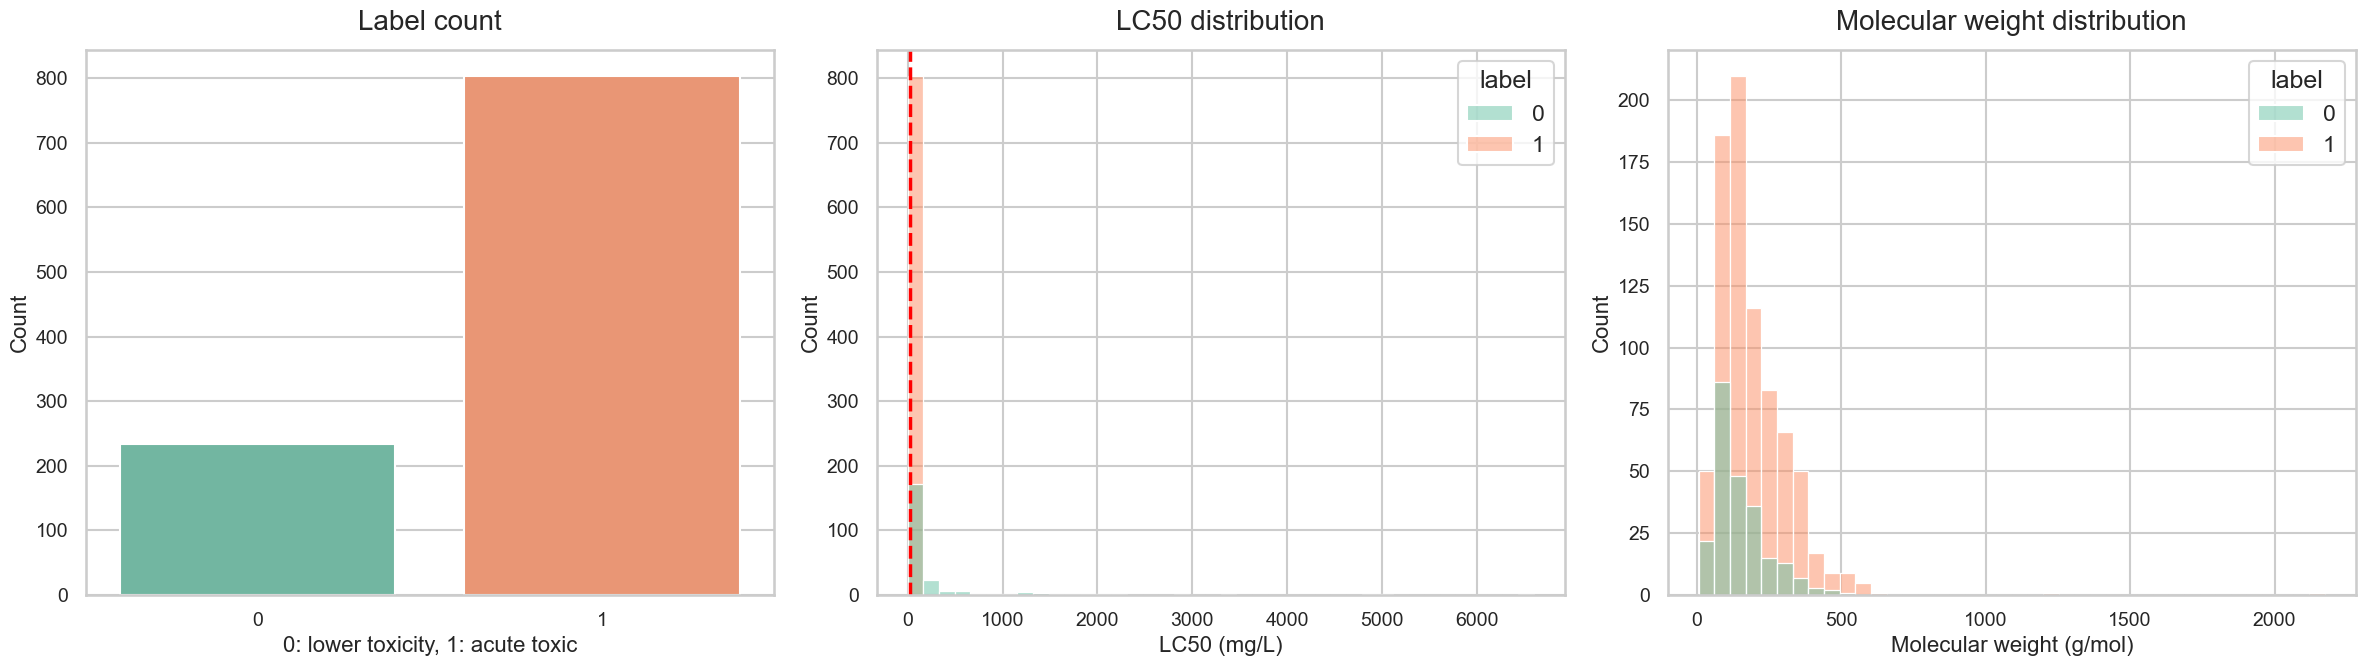

In [8]:
# 8. 데이터 시각화 - label, LC50, 분자량 분포

# acute_oral Template 1과 동일하게, Species 정보가 없거나 의미가 없을 가능성이 있어
# 분자량 분포로 세 번째 그래프를 대체함. 분자량은 SMILES만 있으면 계산 가능함.

sns.set_context('talk')
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.countplot(data=df_final, x='label', ax=axes[0], palette='Set2')
axes[0].set_title('Label count', fontsize=20, pad=14)
axes[0].set_xlabel('0: lower toxicity, 1: acute toxic', fontsize=16)
axes[0].set_ylabel('Count', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)

# [acute_oral과의 차이점]

# x축 단위가 mg/L로, threshold 표시선이 20으로 바뀜.

sns.histplot(data=df_final, x='Response', hue='label', bins=40, ax=axes[1], palette='Set2')
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2.5, label='LC50 20 mg/L')
axes[1].set_title('LC50 distribution', fontsize=20, pad=14)
axes[1].set_xlabel('LC50 (mg/L)', fontsize=16)
axes[1].set_ylabel('Count', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

df_final['MolWt'] = df_final['standardized_smi'].apply(
    lambda smi: Descriptors.MolWt(Chem.MolFromSmiles(smi))
)

sns.histplot(data=df_final, x='MolWt', hue='label', bins=40, ax=axes[2], palette='Set2')
axes[2].set_title('Molecular weight distribution', fontsize=20, pad=14)
axes[2].set_xlabel('Molecular weight (g/mol)', fontsize=16)
axes[2].set_ylabel('Count', fontsize=16)
axes[2].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()


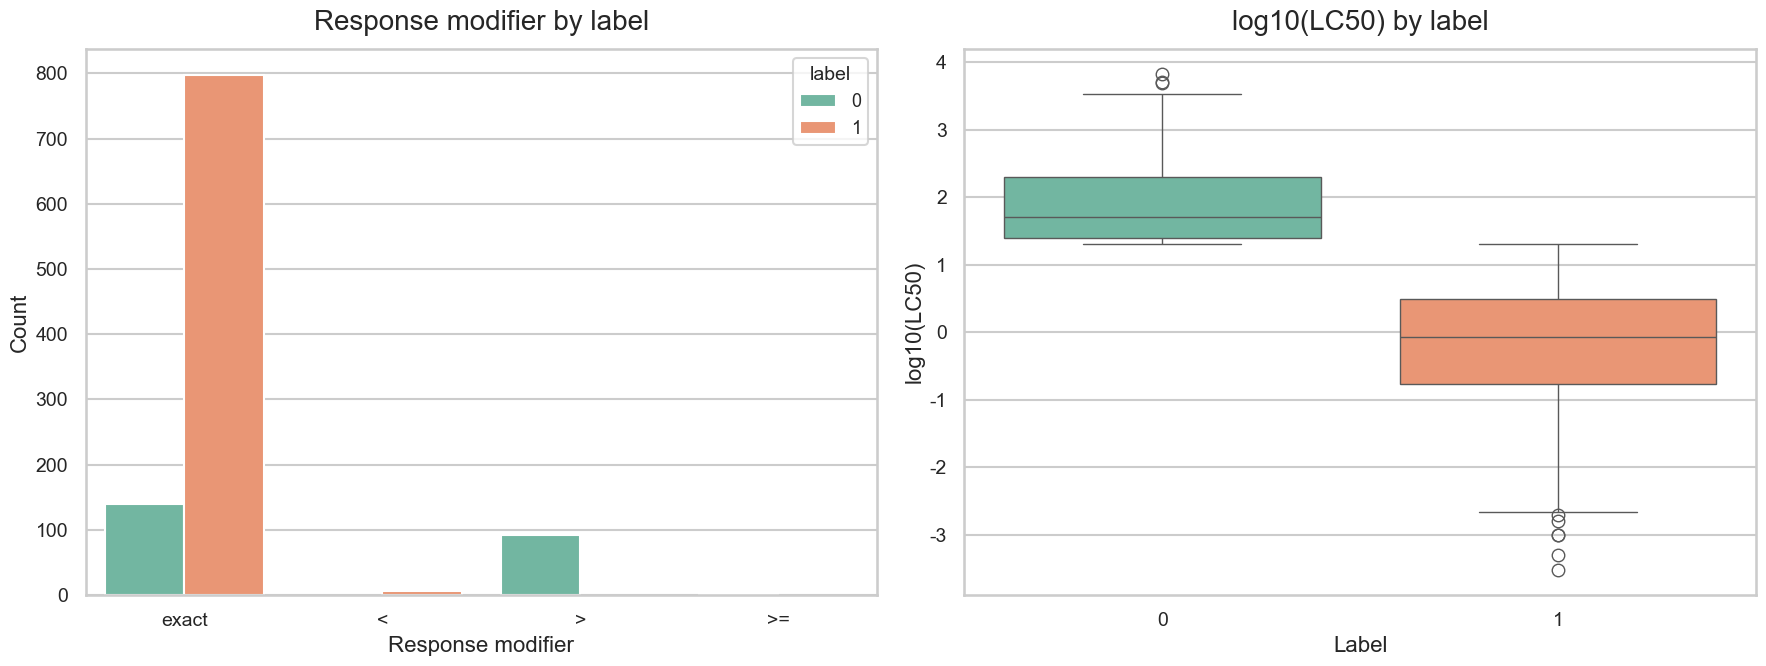

In [9]:
# 9. 데이터 시각화 - response modifier와 log LC50 분포

plot_df = df_final.copy()
plot_df['log10_LC50'] = np.log10(plot_df['Response'])
plot_df['Response_Modifier_filled'] = plot_df['Response_Modifier'].fillna('exact')

sns.set_context('talk')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# [acute_oral과의 차이점]

# modifier 종류에 >= 가 추가로 존재할 수 있으므로 범주가 하나 더 보일 수 있음.

sns.countplot(data=plot_df, x='Response_Modifier_filled', hue='label', ax=axes[0], palette='Set2')
axes[0].set_title('Response modifier by label', fontsize=20, pad=14)
axes[0].set_xlabel('Response modifier', fontsize=16)
axes[0].set_ylabel('Count', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].legend(title='label', fontsize=13, title_fontsize=14)

sns.boxplot(data=plot_df, x='label', y='log10_LC50', ax=axes[1], palette='Set2')
axes[1].set_title('log10(LC50) by label', fontsize=20, pad=14)
axes[1].set_xlabel('Label', fontsize=16)
axes[1].set_ylabel('log10(LC50)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()


In [10]:
# 10. RDKit 2D descriptor 계산
# 이 단계는 SMILES 구조만 입력으로 받으므로 acute_oral과 완전히 동일한 코드를 사용함.

def calc_2d_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        return Descriptors.CalcMolDescriptors(mol)
    except Exception:
        return None

desc_records = []
valid_indices = []

for idx, smi in df_final['standardized_smi'].items():
    desc = calc_2d_descriptors(smi)
    if desc is not None:
        desc_records.append(desc)
        valid_indices.append(idx)

desc_df = pd.DataFrame(desc_records)
df_desc_base = df_final.loc[valid_indices, ['Chemical_Name', 'CASRN', 'SMILES', 'standardized_smi', 'Response', 'Response_Unit', 'label']].reset_index(drop=True)

desc_df = desc_df.replace([np.inf, -np.inf], np.nan)
desc_df = desc_df.dropna(axis=1)

print('Descriptor 계산 성공 화합물 수:', len(df_desc_base))
print('NaN 제거 후 descriptor 개수:', desc_df.shape[1])
display(desc_df.head())


Descriptor 계산 성공 화합물 수: 1037
NaN 제거 후 descriptor 개수: 205


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0.000000,0.000000,0.000000,0.000000,0.319638,0.000000,77.946,74.922,77.945072,8,...,0,0,0,0,0,0,0,0,0,0
1,13.101706,13.101706,0.030453,-0.465519,0.245754,17.285714,523.426,500.242,522.083057,172,...,0,0,0,0,0,0,0,0,0,0
2,7.875000,7.875000,1.750000,1.750000,0.197556,4.000000,47.997,47.997,47.984744,18,...,0,0,0,0,0,0,0,0,0,0
3,2.120370,2.120370,1.253426,1.253426,0.587040,10.142857,186.258,172.146,186.114601,70,...,0,0,0,0,0,0,0,0,0,0
4,7.858333,7.858333,1.362778,-2.461864,0.127319,12.666667,596.117,541.685,598.221856,164,...,0,0,0,0,0,0,0,0,6,0


In [11]:
# 11. Morgan fingerprint 계산
# 마찬가지로 SMILES 구조만 입력으로 받으므로 acute_oral과 완전히 동일한 코드를 사용함.

def calc_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.full(n_bits, np.nan)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

n_bits = 2048
fp_array = np.vstack(df_desc_base['standardized_smi'].apply(lambda x: calc_morgan_fp(x, radius=2, n_bits=n_bits)))
fp_df = pd.DataFrame(fp_array, columns=[f'morgan_{i}' for i in range(n_bits)])

print('Morgan fingerprint shape:', fp_df.shape)
display(fp_df.head())


Morgan fingerprint shape: (1037, 2048)


,morgan_0,morgan_1,morgan_2,morgan_3,morgan_4,morgan_5,morgan_6,morgan_7,morgan_8,morgan_9,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# 12. 최종 데이터셋 저장

final_dataset = pd.concat([df_desc_base, desc_df.reset_index(drop=True), fp_df.reset_index(drop=True)], axis=1)
final_dataset.to_csv(output_path, index=False, encoding='utf-8-sig')

print('최종 데이터셋 크기:', final_dataset.shape)
print('저장 경로:', output_path)
display(final_dataset.head())


최종 데이터셋 크기: (1037, 2260)
저장 경로: C:/Users/elsan/Downloads/final_inhalation_dataset_descriptors.csv


,Chemical_Name,CASRN,SMILES,standardized_smi,Response,Response_Unit,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,Arsine,7784-42-1,[AsH3],[AsH3],0.0003,mg/L,1,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,Brodifacoum,56073-10-0,OC1=C(C2CC(CC3=CC=CC=C23)C2=CC=C(C=C2)C2=CC=C(...,O=c1oc2ccccc2c(O)c1C1CC(c2ccc(-c3ccc(Br)cc3)cc...,0.0005,mg/L,1,13.101706,13.101706,0.030453,...,0,0,0,0,0,0,0,0,0,0
2,Ozone,10028-15-6,[O-][O+]=O,O=[O+][O-],0.0010,mg/L,1,7.875000,7.875000,1.750000,...,0,0,0,0,0,0,0,0,0,0
3,NaN,1910-42-5,[Cl-].[Cl-].C[N+]1=CC=C(C=C1)C1=CC=[N+](C)C=C1,C[n+]1ccc(-c2cc[n+](C)cc2)cc1,0.0010,mg/L,1,2.120370,2.120370,1.253426,...,0,0,0,0,0,0,0,0,0,0
4,Bis(tributyltin)oxide,56-35-9,CCCC[Sn](CCCC)(CCCC)O[Sn](CCCC)(CCCC)CCCC,CCC[CH2][Sn]([CH2]CCC)([CH2]CCC)[O][Sn]([CH2]C...,0.0016,mg/L,1,7.858333,7.858333,1.362778,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# 13. 최종 요약

print('원본 행 수:', len(df_raw))
print('Chemical + LC50 + mg/L + SMILES 행 수:', len(df_lc50))
print('라벨 생성 후 행 수:', len(df_labeled))
print('SMILES 표준화 후 행 수:', len(df_valid))
print('최종 unique compound 수:', len(df_final))
print('최종 descriptor 포함 데이터 크기:', final_dataset.shape)

summary = pd.DataFrame({
    'step': [
        'raw data',
        'chemical LC50 (mg/L) with SMILES',
        'labeled data',
        'valid standardized SMILES',
        'unique non-conflicting compounds',
        'final descriptor dataset'
    ],
    'n_rows': [
        len(df_raw),
        len(df_lc50),
        len(df_labeled),
        len(df_valid),
        len(df_final),
        len(final_dataset)
    ]
})

display(summary)


원본 행 수: 5505
Chemical + LC50 + mg/L + SMILES 행 수: 2976
라벨 생성 후 행 수: 2342
SMILES 표준화 후 행 수: 2300
최종 unique compound 수: 1037
최종 descriptor 포함 데이터 크기: (1037, 2260)


,step,n_rows
0,raw data,5505
1,chemical LC50 (mg/L) with SMILES,2976
2,labeled data,2342
3,valid standardized SMILES,2300
4,unique non-conflicting compounds,1037
5,final descriptor dataset,1037


## 추가 설명

본 파이프라인은 NTP ICE acute inhalation toxicity 데이터에서 단일 화학물질(Chemical)의 LC50 데이터를 사용하였습니다. LC50은 급성 흡입독성의 대표 지표이며, 값이 낮을수록 독성이 강합니다. GHS Category 4 컷오프인 20 mg/L를 기준으로 acute toxic 여부를 이진 라벨로 정의했습니다.

전처리 과정은 acute_oral Template 1과 동일한 원칙(SMILES 결측/변환 실패 제거, salt/fragment 정리, 중복 화합물 및 label 충돌 제거)을 따랐으며, 데이터셋 고유의 특성(LC50 단위 혼재, >= modifier)만 추가로 반영했습니다. Descriptor는 RDKit 2D descriptor와 Morgan fingerprint를 동일하게 계산하여, acute_oral 결과와 동일한 feature 체계로 비교 분석이 가능하도록 했습니다.
